In [ ]:
# @title 1. Install Dependencies
# Install system libraries required for VizDoom
!sudo apt-get update
!sudo apt-get install -y build-essential zlib1g-dev libsdl2-dev libjpeg-dev \
nasm tar libbz2-dev libgtk2.0-dev cmake git libfluidsynth-dev libgme-dev \
libopenal-dev timidity libwildmidi-dev libboost-all-dev

# Install Python libraries
!pip install stable-baselines3 shimmy>=1.3.0 gymnasium vizdoom opencv-python imageio

: 

In [ ]:
import vizdoom
import os
import torch
# Locate where the vizdoom library is installed
scenarios_path = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")

print(f"VizDoom Scenarios found at: {scenarios_path}")
print("Files available:", os.listdir(scenarios_path))

# Check specifically for Defend the Center
if "defend_the_center.wad" in os.listdir(scenarios_path):
    print("\n✅ SUCCESS: 'defend_the_center.wad' is present and ready to use!")
else:
    print("\n❌ ERROR: Game files missing.")

In [ ]:
# @title 2. Train and Evaluate Agent (Bulletproof Custom Class)
import os
import time
import json
import cv2
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import imageio
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecTransposeImage
from IPython.display import Image, display

# --- COLAB SPECIFIC CONFIGURATION ---
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Hyperparameters
CONFIG = {
    "timesteps": 1000000,
    "n_envs": 4,
    "frame_skip": 4,
    "n_steps": 512,
    "batch_size": 64,
    "learning_rate": 2.5e-4,
    "eval_episodes": 5,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "log_dir": "/content/logs"
}

# --- 1. DEFINE CUSTOM ENVIRONMENT CLASS ---
# This bypasses all registry errors by wrapping VizDoom manually.
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # 1. Locate Config File
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")

        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        # 2. Initialize Game
        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)
        self.game.init()

        # 3. Define Spaces
        # Action space: 3 buttons (Turn Left, Turn Right, Attack)
        self.action_space = spaces.Discrete(3)

        # Observation space: The raw screen (H, W, 3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

    def step(self, action):
        # Convert Discrete(3) to One-Hot for VizDoom
        # Buttons: [Turn Left, Turn Right, Attack]
        actions = [0.0] * 3
        actions[action] = 1.0

        reward = self.game.make_action(actions, self.frame_skip)
        done = self.game.is_episode_finished()

        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer # Already RGB24
            info = {}
        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            info = {
                "kills": self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT),
                "frags": self.game.get_game_variable(vizdoom.GameVariable.FRAGCOUNT)
            }
            # Important: Reset required by Gym interface if done, but VecEnv handles it.
            # However, standard Gym envs wait for reset().

        return {"screen": screen}, reward, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()

        state = self.game.get_state()
        screen = state.screen_buffer
        return {"screen": screen}, {}

    def close(self):
        self.game.close()

# --- 2. Custom Wrapper for Resizing ---
class ObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env, shape=(60, 80)):
        super().__init__(env)
        self.image_shape = shape
        self.image_shape_cv = shape[::-1]

        obs_shape = env.observation_space["screen"].shape
        new_shape = (shape[0], shape[1], obs_shape[-1])
        self.observation_space = gym.spaces.Box(0, 255, shape=new_shape, dtype=np.uint8)

    def observation(self, observation):
        screen = observation["screen"]
        resized = cv2.resize(screen, self.image_shape_cv, interpolation=cv2.INTER_AREA)
        return resized

# Factory to instantiate our Custom Class
def make_wrapped_env(frame_skip, monitor_dir=None, seed=0):
    def _init():
        env = VizDoomDefendCenter(frame_skip=frame_skip) # <--- Direct Instantiation
        env = ObservationWrapper(env)
        env = gym.wrappers.TransformReward(env, lambda r: r * 0.01)
        if monitor_dir:
            os.makedirs(monitor_dir, exist_ok=True)
            env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
        else:
            env = Monitor(env)
        return env
    return _init

# --- 3. Custom Callbacks ---
class DoomMetricsCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=5000, n_eval_episodes=5, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes

    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            kills, frags = [], []
            obs = self.eval_env.reset()
            for _ in range(self.n_eval_episodes):
                done = False
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, _, dones, infos = self.eval_env.step(action)
                    if dones[0]:
                        done = True
                        info = infos[0]
                        kills.append(info.get("kills", 0))
                        frags.append(info.get("frags", 0))

            if kills:
                self.logger.record("game/mean_kills", np.mean(kills))
                self.logger.record("game/mean_frags", np.mean(frags))
        return True

# --- 4. Main Training Flow ---

print(f"Training on: {CONFIG['device']}")

# Create Training Environment
# Note: We pass our factory function directly to make_vec_env
train_env = make_vec_env(
    make_wrapped_env(CONFIG['frame_skip'], CONFIG['log_dir']),
    n_envs=CONFIG['n_envs'],
    seed=CONFIG['seed']
)
train_env = VecTransposeImage(train_env)

# Create Evaluation Environment
eval_env = make_vec_env(
    make_wrapped_env(CONFIG['frame_skip'], None),
    n_envs=1,
    seed=CONFIG['seed'] + 1000
)
eval_env = VecTransposeImage(eval_env)

# Initialize Model
policy_kwargs = dict(features_extractor_kwargs=dict(features_dim=512)) if CONFIG['device'] == "cuda" else {}

model = PPO(
    "CnnPolicy",
    train_env,
    verbose=1,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device'],
    policy_kwargs=policy_kwargs,
    seed=CONFIG['seed'],
    tensorboard_log=os.path.join(CONFIG['log_dir'], "tensorboard")
)

# Train
print("Starting Training...")
model.learn(
    total_timesteps=CONFIG['timesteps'],
    callback=DoomMetricsCallback(eval_env, eval_freq=5000, n_eval_episodes=CONFIG['eval_episodes'])
)

# Save Model
model_path = os.path.join(CONFIG['log_dir'], "ppo_defend_center_colab.zip")
model.save(model_path)
print(f"Model saved to {model_path}")

# --- 5. Final Evaluation & GIF Generation ---
print("Generating Replay GIF...")
gif_env = make_wrapped_env(CONFIG['frame_skip'], None)()

frames = []
obs, _ = gif_env.reset()
done = False

while not done:
    # Our custom env returns RGB, no conversion needed usually
    if obs.shape[-1] == 1:
        frame = cv2.cvtColor(obs, cv2.COLOR_GRAY2RGB)
    else:
        frame = obs
    frames.append(frame)

    img = np.transpose(obs, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    action, _ = model.predict(img, deterministic=True)
    obs, _, terminated, truncated, _ = gif_env.step(action.item())
    done = terminated or truncated

gif_env.close()

gif_path = os.path.join(CONFIG['log_dir'], "colab_gameplay.gif")
imageio.mimsave(gif_path, frames, fps=30)

print(f"GIF saved to {gif_path}")
display(Image(filename=gif_path))

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/logs/tensorboard

In [ ]:
# @title 4. High-Resolution Recording (640x480)
import cv2
import numpy as np
import imageio
import os
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution
from stable_baselines3 import PPO
from IPython.display import Image, display

# Configuration
MODEL_PATH = "/content/logs/ppo_defend_center_colab.zip"  # Path to your saved model
OUTPUT_FILE = "/content/logs/gameplay_hd.gif"
RESOLUTION = ScreenResolution.RES_640X480  # Much higher than training
FRAME_SKIP = 4

# --- 1. Define HD Environment Class ---
# This looks similar to the training class, but with higher resolution settings
class VizDoomHD:
    def __init__(self, model_path):
        # Locate Config
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")

        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)

        # --- KEY CHANGE: Set High Resolution ---
        self.game.set_screen_resolution(RESOLUTION)
        self.game.init()

        # Load the trained agent
        print(f"Loading model from: {model_path}")
        self.model = PPO.load(model_path)

    def preprocess(self, screen_buffer):
        """
        Takes the HD screen (640x480) and shrinks it to what the agent expects (80x60).
        """
        # Resize to match the agent's training input (W=80, H=60)
        # Note: cv2.resize expects (Width, Height)
        resized = cv2.resize(screen_buffer, (80, 60), interpolation=cv2.INTER_AREA)

        # Re-order dimensions for PyTorch: (H, W, C) -> (C, H, W)
        obs = np.transpose(resized, (2, 0, 1))

        # Add batch dimension: (1, C, H, W)
        obs = np.expand_dims(obs, axis=0)
        return obs

    def record_episode(self, filename):
        frames = []
        self.game.new_episode()

        print("Recording HD Episode...")
        while not self.game.is_episode_finished():
            state = self.game.get_state()
            hd_screen = state.screen_buffer  # This is the 640x480 image

            # 1. Save HD frame for the video
            frames.append(hd_screen)

            # 2. Preprocess frame for the Agent
            agent_input = self.preprocess(hd_screen)

            # 3. Agent predicts action
            action, _ = self.model.predict(agent_input, deterministic=True)

            # 4. Convert Agent action (index) to VizDoom action (one-hot)
            # Buttons: [Turn Left, Turn Right, Attack]
            do_action = [0.0] * 3
            do_action[action.item()] = 1.0

            self.game.make_action(do_action, FRAME_SKIP)

        self.game.close()

        # Save to GIF
        print(f"Saving {len(frames)} HD frames to {filename}...")
        imageio.mimsave(filename, frames, fps=25)
        print("Done!")

# --- Run the Recorder ---
if os.path.exists(MODEL_PATH):
    recorder = VizDoomHD(MODEL_PATH)
    recorder.record_episode(OUTPUT_FILE)

    # Display
    display(Image(filename=OUTPUT_FILE))
else:
    print(f"Error: Model not found at {MODEL_PATH}. Did you finish training?")

In [ ]:
# @title 6. Explainable AI: Saliency Map Visualization (Fixed)
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

def compute_saliency(model, raw_obs):
    """
    Computes gradients. Handles shape mismatch between Gym (H,W,C) and PyTorch (C,H,W).
    """
    # 1. Prepare the image for the model
    # The model expects (Channels, Height, Width), but raw_obs is (Height, Width, Channels)
    # We transpose it to (2, 0, 1) -> (3, 60, 80)
    if raw_obs.shape[-1] == 3:
        obs_for_model = np.transpose(raw_obs, (2, 0, 1))
    else:
        obs_for_model = raw_obs

    # Convert to Tensor
    obs_tensor, _ = model.policy.obs_to_tensor(obs_for_model)

    # FIX: Cast to float to allow gradient calculation
    obs_tensor = obs_tensor.float()
    obs_tensor.requires_grad_(True)

    # 2. Get the Policy's prediction
    distribution = model.policy.get_distribution(obs_tensor)
    logits = distribution.distribution.logits
    best_action_idx = torch.argmax(logits, dim=1)
    best_action_score = logits[0, best_action_idx]

    # 3. Backpropagate
    model.policy.zero_grad()
    best_action_score.backward()

    # 4. Extract Saliency
    grads = obs_tensor.grad.squeeze().cpu().detach().numpy()

    # The gradients come out as (Channels, Height, Width) -> (3, 60, 80)
    # We want a 2D heatmap -> (60, 80)
    if len(grads.shape) == 3:
        saliency_map = np.max(np.abs(grads), axis=0) # Collapse channels
    else:
        saliency_map = np.abs(grads)

    # Normalize
    saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)

    return saliency_map, best_action_idx.item()

# --- Run the Analysis ---

# 1. Create env
analysis_env = make_wrapped_env(CONFIG['frame_skip'], None)()
obs, _ = analysis_env.reset()

# Skip frames to find a monster
print("Skipping frames to find a monster...")
for _ in range(20):
    obs, _, _, _, _ = analysis_env.step(0)

# 2. Compute Saliency
# Note: obs is (60, 80, 3) here
saliency, action_id = compute_saliency(model, obs)

action_names = {0: "Turn Left", 1: "Turn Right", 2: "Attack"}
chosen_action = action_names.get(action_id, "Unknown")

# 3. Visualization
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# FIX: Do NOT transpose here. Matplotlib likes (60, 80, 3).
original_frame = obs

# Ensure it's valid for matplotlib
if original_frame.max() > 1.0:
    display_frame = original_frame.astype(float) / 255.0
else:
    display_frame = original_frame

ax[0].imshow(display_frame)
ax[0].set_title("What the Agent Sees")
ax[0].axis('off')

# Saliency Heatmap
im = ax[1].imshow(saliency, cmap='hot', interpolation='bilinear')
ax[1].set_title(f"Attention Map (Agent Chose: {chosen_action})")
ax[1].axis('off')

# Overlay
# Convert heatmap to RGB (Height, Width, 3)
heatmap_colored = plt.get_cmap('hot')(saliency)[:, :, :3]

# Combine: 50% Image + 50% Heatmap
overlay = display_frame * 0.5 + heatmap_colored * 0.5

ax[2].imshow(overlay)
ax[2].set_title("Overlay (Hot = High Attention)")
ax[2].axis('off')

plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

analysis_env.close()

In [ ]:
# @title 7. Generate HD Saliency Video (Overlay)
import cv2
import numpy as np
import imageio
import torch
import matplotlib.pyplot as plt
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution

# Config
HD_RESOLUTION = ScreenResolution.RES_640X480
OUTPUT_GIF = "/content/logs/hd_saliency.gif"
MODEL_PATH = "/content/logs/ppo_defend_center_colab.zip"

def get_saliency_map(model, low_res_obs):
    """
    Calculate saliency on the low-res observation.
    Returns a normalized 2D map (Height, Width).
    """
    # Prepare observation for model (Transpose HWC -> CHW)
    if low_res_obs.shape[-1] == 3:
        obs_for_model = np.transpose(low_res_obs, (2, 0, 1))
    else:
        obs_for_model = low_res_obs

    # Convert to tensor
    obs_tensor, _ = model.policy.obs_to_tensor(obs_for_model)
    obs_tensor = obs_tensor.float()
    obs_tensor.requires_grad_(True)

    # Get prediction and gradients
    distribution = model.policy.get_distribution(obs_tensor)
    logits = distribution.distribution.logits
    best_action_idx = torch.argmax(logits, dim=1)
    best_action_score = logits[0, best_action_idx]

    model.policy.zero_grad()
    best_action_score.backward()

    # Process gradients
    grads = obs_tensor.grad.squeeze().cpu().detach().numpy()
    if len(grads.shape) == 3:
        saliency = np.max(np.abs(grads), axis=0)
    else:
        saliency = np.abs(grads)

    # Normalize
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency, best_action_idx.item()

# --- Initialize HD Game ---
game = DoomGame()
game.load_config(os.path.join(scenarios_path, "defend_the_center.cfg"))
game.set_screen_resolution(HD_RESOLUTION) # 640x480
game.set_screen_format(ScreenFormat.RGB24)
game.set_window_visible(False)
game.init()

# Load Model
model = PPO.load(MODEL_PATH)

frames = []
print("Recording HD Saliency Episode...")
game.new_episode()

while not game.is_episode_finished():
    state = game.get_state()
    hd_frame = state.screen_buffer # 640x480 RGB

    # 1. Downscale for the Agent (Agent needs 80x60)
    low_res_frame = cv2.resize(hd_frame, (80, 60), interpolation=cv2.INTER_AREA)

    # 2. Calculate Saliency on the low-res frame
    saliency_map, action = get_saliency_map(model, low_res_frame)

    # 3. Upscale Saliency Map to HD (60x80 -> 480x640)
    # We use INTER_CUBIC to make the "heat" look smooth, not blocky
    saliency_hd = cv2.resize(saliency_map, (640, 480), interpolation=cv2.INTER_CUBIC)

    # 4. Apply Colormap (Hot)
    # plt.cm.hot returns RGBA, we only need RGB. Result is 0-1 float.
    heatmap_colored = plt.get_cmap('hot')(saliency_hd)[:, :, :3]

    # Convert HD frame to 0-1 float for blending
    hd_frame_norm = hd_frame.astype(float) / 255.0

    # 5. Blend: 60% Game, 40% Heatmap
    # We boost the heatmap intensity slightly (clip to 1.0)
    overlay = (hd_frame_norm * 0.6) + (heatmap_colored * 0.4)
    overlay = np.clip(overlay, 0, 1)

    # Convert back to uint8 for GIF
    final_frame = (overlay * 255).astype(np.uint8)
    frames.append(final_frame)

    # 6. Step the game
    actions = [0.0] * 3
    actions[action] = 1.0
    game.make_action(actions, 4) # Frame skip 4

game.close()

# Save GIF
print(f"Saving {len(frames)} frames to {OUTPUT_GIF}...")
imageio.mimsave(OUTPUT_GIF, frames, fps=25)
print("Done!")

from IPython.display import Image, display
display(Image(filename=OUTPUT_GIF))

In [ ]:
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # 1. Locate Config File
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")

        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        # 2. Initialize Game
        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)
        self.game.init()

        # 3. Define Spaces
        self.action_space = spaces.Discrete(3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

    def step(self, action):
        # --- NEW: Capture stats BEFORE action ---
        # AMMO2 is the pistol ammo variable in Doom
        ammo_before = self.game.get_game_variable(vizdoom.GameVariable.AMMO2)
        kills_before = self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT)

        # Convert Discrete(3) to One-Hot
        actions = [0.0] * 3
        actions[action] = 1.0

        # Make action
        reward = self.game.make_action(actions, self.frame_skip)
        done = self.game.is_episode_finished()

        # --- NEW: Custom Reward Shaping (Ammo Penalty) ---
        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer
            info = {}

            # Capture stats AFTER action
            ammo_after = self.game.get_game_variable(vizdoom.GameVariable.AMMO2)
            kills_after = self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT)

            # Logic: If we lost ammo but didn't get a kill, penalize!
            # We use a small penalty (e.g., -0.2).
            # If it's too high, the agent will become pacifist and refuse to shoot.
            if (ammo_before > ammo_after) and (kills_before == kills_after):
                reward -= 0.2  # <--- THE AMMO PENALTY

        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            info = {
                "kills": self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT),
                "frags": self.game.get_game_variable(vizdoom.GameVariable.FRAGCOUNT)
            }

        return {"screen": screen}, reward, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()

        state = self.game.get_state()
        screen = state.screen_buffer
        return {"screen": screen}, {}

    def close(self):
        self.game.close()

In [ ]:
# @title 2. Train and Evaluate Agent (With Ammo Saving Mechanism)
import os
import time
import json
import cv2
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import imageio
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecTransposeImage
from IPython.display import Image, display

# --- COLAB SPECIFIC CONFIGURATION ---
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Hyperparameters
CONFIG = {
    "timesteps": 100000,
    "n_envs": 4,
    "frame_skip": 4,
    "n_steps": 512,
    "batch_size": 64,
    "learning_rate": 2.5e-4,
    "eval_episodes": 5,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "log_dir": "/content/logs"
}

# --- 1. DEFINE CUSTOM ENVIRONMENT CLASS ---
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # 1. Locate Config File
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")

        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        # 2. Initialize Game
        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)
        self.game.init()

        # 3. Define Spaces
        self.action_space = spaces.Discrete(3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

    def step(self, action):
        # --- NEW: Capture stats BEFORE action ---
        # AMMO2 is the pistol ammo variable in Doom
        ammo_before = self.game.get_game_variable(vizdoom.GameVariable.AMMO2)
        kills_before = self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT)

        # Convert Discrete(3) to One-Hot
        actions = [0.0] * 3
        actions[action] = 1.0

        # Make action
        reward = self.game.make_action(actions, self.frame_skip)
        done = self.game.is_episode_finished()

        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer
            info = {}

            # --- NEW: Custom Reward Shaping (Ammo Penalty) ---
            ammo_after = self.game.get_game_variable(vizdoom.GameVariable.AMMO2)
            kills_after = self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT)

            # Logic: If ammo decreased but kills didn't increase -> We missed!
            # Penalty: -0.5. (Note: The wrapper later scales this by 0.01)
            if (ammo_before > ammo_after) and (kills_before == kills_after):
                reward -= 0.25

        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            info = {
                "kills": self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT),
                "frags": self.game.get_game_variable(vizdoom.GameVariable.FRAGCOUNT)
            }

        return {"screen": screen}, reward, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()

        state = self.game.get_state()
        screen = state.screen_buffer
        return {"screen": screen}, {}

    def close(self):
        self.game.close()

# --- 2. Custom Wrapper for Resizing ---
class ObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env, shape=(60, 80)):
        super().__init__(env)
        self.image_shape = shape
        self.image_shape_cv = shape[::-1]

        obs_shape = env.observation_space["screen"].shape
        new_shape = (shape[0], shape[1], obs_shape[-1])
        self.observation_space = gym.spaces.Box(0, 255, shape=new_shape, dtype=np.uint8)

    def observation(self, observation):
        screen = observation["screen"]
        resized = cv2.resize(screen, self.image_shape_cv, interpolation=cv2.INTER_AREA)
        return resized

# Factory to instantiate our Custom Class
def make_wrapped_env(frame_skip, monitor_dir=None, seed=0):
    def _init():
        env = VizDoomDefendCenter(frame_skip=frame_skip)
        env = ObservationWrapper(env)
        # Keeps your original scaling (x 0.01)
        env = gym.wrappers.TransformReward(env, lambda r: r * 0.01)
        if monitor_dir:
            os.makedirs(monitor_dir, exist_ok=True)
            env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
        else:
            env = Monitor(env)
        return env
    return _init

# --- 3. Custom Callbacks ---
class DoomMetricsCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=5000, n_eval_episodes=5, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes

    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            kills, frags = [], []
            obs = self.eval_env.reset()
            for _ in range(self.n_eval_episodes):
                done = False
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, _, dones, infos = self.eval_env.step(action)
                    if dones[0]:
                        done = True
                        info = infos[0]
                        kills.append(info.get("kills", 0))
                        frags.append(info.get("frags", 0))

            if kills:
                self.logger.record("game/mean_kills", np.mean(kills))
                self.logger.record("game/mean_frags", np.mean(frags))
        return True

# --- 4. Main Training Flow ---

print(f"Training on: {CONFIG['device']}")

# Create Training Environment
train_env = make_vec_env(
    make_wrapped_env(CONFIG['frame_skip'], CONFIG['log_dir']),
    n_envs=CONFIG['n_envs'],
    seed=CONFIG['seed']
)
train_env = VecTransposeImage(train_env)

# Create Evaluation Environment
eval_env = make_vec_env(
    make_wrapped_env(CONFIG['frame_skip'], None),
    n_envs=1,
    seed=CONFIG['seed'] + 1000
)
eval_env = VecTransposeImage(eval_env)

# Initialize Model
policy_kwargs = dict(features_extractor_kwargs=dict(features_dim=512)) if CONFIG['device'] == "cuda" else {}

model = PPO(
    "CnnPolicy",
    train_env,
    verbose=1,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device'],
    policy_kwargs=policy_kwargs,
    seed=CONFIG['seed'],
    tensorboard_log=os.path.join(CONFIG['log_dir'], "tensorboard")
)

# Train
print("Starting Training...")
model.learn(
    total_timesteps=CONFIG['timesteps'],
    callback=DoomMetricsCallback(eval_env, eval_freq=5000, n_eval_episodes=CONFIG['eval_episodes'])
)

# Save Model
model_path = os.path.join(CONFIG['log_dir'], "ppo_defend_center_colab.zip")
model.save(model_path)
print(f"Model saved to {model_path}")

# --- 5. Final Evaluation & GIF Generation ---
print("Generating Replay GIF...")
gif_env = make_wrapped_env(CONFIG['frame_skip'], None)()

frames = []
obs, _ = gif_env.reset()
done = False

while not done:
    if obs.shape[-1] == 1:
        frame = cv2.cvtColor(obs, cv2.COLOR_GRAY2RGB)
    else:
        frame = obs
    frames.append(frame)

    img = np.transpose(obs, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    action, _ = model.predict(img, deterministic=True)
    obs, _, terminated, truncated, _ = gif_env.step(action.item())
    done = terminated or truncated

gif_env.close()

gif_path = os.path.join(CONFIG['log_dir'], "colab_gameplay.gif")
imageio.mimsave(gif_path, frames, fps=30)

print(f"GIF saved to {gif_path}")
display(Image(filename=gif_path))

In [ ]:
# @title 8. X-Ray Vision: Deep Network Layers (Right Before Flatten)
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import io
import os
from stable_baselines3 import PPO

# --- CONFIG ---
MODEL_PATH = "/content/logs/ppo_defend_center_colab.zip"
OUTPUT_PATH = "/content/logs/deep_filters_visualization.gif"

# Load Model
if os.path.exists(MODEL_PATH):
    model = PPO.load(MODEL_PATH)
else:
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

def get_last_layer_features(model, obs):
    """Pass input through ALL CNN layers and catch the output of the LAST Conv2d."""
    cnn_layers = model.policy.features_extractor.cnn

    # Prepare Input
    if len(obs.shape) == 3 and obs.shape[-1] == 3:
        obs_transposed = np.transpose(obs, (2, 0, 1))
    else:
        obs_transposed = obs

    obs_tensor = torch.as_tensor(obs_transposed).float().unsqueeze(0).to(model.device)

    # --- LOOP THROUGH ALL LAYERS ---
    last_conv_output = None

    for layer in cnn_layers:
        obs_tensor = layer(obs_tensor)

        # If this layer is a Convolution, save its output
        # As we loop, this variable gets overwritten, so at the end
        # it will hold the result of the FINAL Conv2d layer.
        if isinstance(layer, nn.Conv2d):
            last_conv_output = obs_tensor.clone()

    if last_conv_output is not None:
        return last_conv_output.squeeze(0).cpu().detach().numpy()
    return None

def plot_deep_filters(features):
    """Visualize low-res deep features."""

    # Setup Figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=100)
    fig.suptitle(f"Deep Feature Maps (Abstract Concepts)", fontsize=16)

    if not isinstance(axes, np.ndarray):
        axes = [axes]

    for i in range(2):
        ax = axes[i]
        if i < features.shape[0]:
            # We use 'nearest' interpolation to show the raw pixels clearly
            # or 'bicubic' to smooth them out.
            # 'nearest' is scientifically more accurate for low-res maps.
            im = ax.imshow(features[i], cmap='inferno', interpolation='nearest')
            ax.set_title(f"Deep Filter #{i+1}\n({features.shape[1]}x{features.shape[2]} pixels)", fontsize=12)
        ax.axis('off')

    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    plt.close(fig)
    return img

# --- Execution ---

print("Running deep layer analysis...")
sample_env = make_wrapped_env(CONFIG['frame_skip'], None)()
obs, _ = sample_env.reset()
obs_list = [obs]

# Record 100 frames
for step in range(100):
    action, _ = model.predict(obs, deterministic=False)
    obs, reward, terminated, truncated, _ = sample_env.step(action)
    obs_list.append(obs.copy())
    if terminated or truncated:
        break
sample_env.close()

# Generate Frames
print(f"Processing {len(obs_list)} frames...")
gif_frames = []

for i, obs in enumerate(obs_list):
    features = get_last_layer_features(model, obs)
    if features is not None:
        img = plot_deep_filters(features)
        gif_frames.append(img)
        if i % 20 == 0: print(f" Processed {i}...")

# Save GIF
if gif_frames:
    gif_frames[0].save(
        OUTPUT_PATH,
        save_all=True,
        append_images=gif_frames[1:],
        duration=50,
        loop=0
    )
    print(f"\n✅ DEEP LAYER GIF SAVED: {OUTPUT_PATH}")
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=OUTPUT_PATH))

In [ ]:
# @title 8. X-Ray Vision: Middle Layer (Shapes & Textures)
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import io
import os
from stable_baselines3 import PPO

# --- CONFIG ---
MODEL_PATH = "/content/logs/ppo_defend_center_colab.zip"
OUTPUT_PATH = "/content/logs/middle_layer_visualization.gif"

# Load Model
if os.path.exists(MODEL_PATH):
    model = PPO.load(MODEL_PATH)
else:
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

def get_middle_layer_features(model, obs):
    """
    Pass input through CNN and stop at the Second-to-Last Conv Layer.
    """
    cnn = model.policy.features_extractor.cnn

    # 1. Identify which layers are Convolutions
    conv_indices = [i for i, layer in enumerate(cnn) if isinstance(layer, nn.Conv2d)]

    # We want the second to last one (Index -2)
    # If the network is small and only has 2 layers, this will grab the first one.
    if len(conv_indices) >= 2:
        target_layer_idx = conv_indices[-2]
    else:
        target_layer_idx = conv_indices[0] # Fallback for small nets

    # 2. Prepare Input
    if len(obs.shape) == 3 and obs.shape[-1] == 3:
        obs_transposed = np.transpose(obs, (2, 0, 1))
    else:
        obs_transposed = obs

    obs_tensor = torch.as_tensor(obs_transposed).float().unsqueeze(0).to(model.device)

    # 3. Pass through layers until we hit the target
    for i, layer in enumerate(cnn):
        obs_tensor = layer(obs_tensor)
        if i == target_layer_idx:
            # STOP HERE and return the "Shape" features
            return obs_tensor.squeeze(0).cpu().detach().numpy()

    return None

def plot_middle_filters(features):
    """Visualize middle-layer features."""

    # Setup Figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=100)
    fig.suptitle(f"Middle Layer: Shapes & Textures", fontsize=16)

    if not isinstance(axes, np.ndarray):
        axes = [axes]

    for i in range(2):
        ax = axes[i]
        if i < features.shape[0]:
            # 'cividis' is great for seeing texture gradients
            im = ax.imshow(features[i], cmap='cividis', interpolation='nearest')
            ax.set_title(f"Shape Filter #{i+1}\n({features.shape[1]}x{features.shape[2]} px)", fontsize=12)
        ax.axis('off')

    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    plt.close(fig)
    return img

# --- Execution ---

print("Running middle layer analysis...")
sample_env = make_wrapped_env(CONFIG['frame_skip'], None)()
obs, _ = sample_env.reset()
obs_list = [obs]

# Record 100 frames
for step in range(100):
    action, _ = model.predict(obs, deterministic=False)
    obs, reward, terminated, truncated, _ = sample_env.step(action)
    obs_list.append(obs.copy())
    if terminated or truncated:
        break
sample_env.close()

# Generate Frames
print(f"Processing {len(obs_list)} frames...")
gif_frames = []

for i, obs in enumerate(obs_list):
    features = get_middle_layer_features(model, obs)
    if features is not None:
        img = plot_middle_filters(features)
        gif_frames.append(img)

# Save GIF
if gif_frames:
    gif_frames[0].save(
        OUTPUT_PATH,
        save_all=True,
        append_images=gif_frames[1:],
        duration=50,
        loop=0
    )
    print(f"\n✅ MIDDLE LAYER GIF SAVED: {OUTPUT_PATH}")
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=OUTPUT_PATH))

In [ ]:
# @title 9. Side-by-Side Comparison: "Eyes vs. Brain" (Slow Motion)
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import io
import os
from stable_baselines3 import PPO

# --- CONFIG ---
MODEL_PATH = "/content/ppo_defend_center_colab.zip"
OUTPUT_PATH = "/content/logs/eyes_vs_brain_slowmo.gif"
FPS = 5  # Slow motion (5 frames per second)

# Load Model
if os.path.exists(MODEL_PATH):
    model = PPO.load(MODEL_PATH)
else:
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

def get_last_layer_activity(model, obs):
    """
    Get the activity of the final Convolutional Layer.
    Returns the MAX activation across all filters (The 'Hotspot' map).
    """
    cnn = model.policy.features_extractor.cnn

    # Prepare Input
    if len(obs.shape) == 3 and obs.shape[-1] == 3:
        obs_transposed = np.transpose(obs, (2, 0, 1))
    else:
        obs_transposed = obs

    obs_tensor = torch.as_tensor(obs_transposed).float().unsqueeze(0).to(model.device)

    # Loop through layers to get the last Conv2d output
    last_output = None
    for layer in cnn:
        obs_tensor = layer(obs_tensor)
        if isinstance(layer, nn.Conv2d):
            last_output = obs_tensor.clone()

    if last_output is not None:
        # Shape is (1, 64, H, W)
        # We take the MAX across the 64 filters to see "Where is the network most excited?"
        features = last_output.squeeze(0).cpu().detach().numpy()
        max_activation = np.max(features, axis=0)
        return max_activation
    return None

def create_side_by_side_frame(game_frame, brain_map):
    """
    Stitches the Game Frame and the Brain Map into one image.
    """
    # Create a figure with 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='black')

    # --- LEFT: THE EYES (Game Screen) ---
    axes[0].imshow(game_frame)
    axes[0].set_title("Agent Eyes (Input)", color='white', fontsize=14)
    axes[0].axis('off')

    # --- RIGHT: THE BRAIN (Last Layer) ---
    # We use 'nearest' interpolation to show the raw, blocky grid of the neural net
    im = axes[1].imshow(brain_map, cmap='inferno', interpolation='nearest')
    axes[1].set_title("Agent Brain (Concept Map)", color='white', fontsize=14)
    axes[1].axis('off')

    # Add a subtle grid to the brain map to emphasize it's a grid of neurons
    h, w = brain_map.shape
    axes[1].set_xticks(np.arange(-.5, w, 1), minor=True)
    axes[1].set_yticks(np.arange(-.5, h, 1), minor=True)
    axes[1].grid(which='minor', color='black', linestyle='-', linewidth=1, alpha=0.3)

    plt.tight_layout()

    # Convert to PIL
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', facecolor='black')
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    plt.close(fig)
    return img

# --- EXECUTION ---

print("Running Side-by-Side simulation...")
sample_env = make_wrapped_env(CONFIG['frame_skip'], None)()
obs, _ = sample_env.reset()
obs_list = [obs]

# Record 100 steps (approx 3-4 seconds of gameplay)
for step in range(100):
    action, _ = model.predict(obs, deterministic=False)
    obs, reward, terminated, truncated, _ = sample_env.step(action)
    obs_list.append(obs.copy())
    if terminated or truncated:
        break
sample_env.close()

# Generate Frames
print(f"Rendering {len(obs_list)} comparison frames...")
gif_frames = []

for i, obs in enumerate(obs_list):
    # Get the "Brain" map
    brain_activity = get_last_layer_activity(model, obs)

    if brain_activity is not None:
        # Create the combined image
        img = create_side_by_side_frame(obs, brain_activity)
        gif_frames.append(img)

    if i % 20 == 0: print(f" Processed {i}/{len(obs_list)}")

# Save GIF
if gif_frames:
    duration_per_frame = int(1000 / FPS) # Convert FPS to Milliseconds

    gif_frames[0].save(
        OUTPUT_PATH,
        save_all=True,
        append_images=gif_frames[1:],
        duration=duration_per_frame,
        loop=0
    )
    print(f"\n✅ SIDE-BY-SIDE GIF SAVED: {OUTPUT_PATH}")
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=OUTPUT_PATH))

In [ ]:
# @title 2. Train and Evaluate Conditioned Agent (Multi-Objective)
import os
import time
import cv2
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import imageio
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution, GameVariable
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
# Note: We removed VecTransposeImage because MultiInputPolicy handles transposing internally for Dict obs

# --- COLAB SPECIFIC CONFIGURATION ---
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Hyperparameters
CONFIG = {
    "timesteps": 600000,       # Reduced for testing (increase to 1.5M for paper)
    "n_envs": 4,
    "frame_skip": 4,
    "n_steps": 512,
    "batch_size": 64,
    "learning_rate": 2.0e-4,
    "eval_episodes": 5,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "log_dir": "/content/logs_multiobj"
}

# --- 1. DEFINE BASE ENVIRONMENT ---
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # 1. Locate Config
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")
        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        # 2. Initialize Game
        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)

        # Enable variables we need for Multi-Objective Rewards
        self.game.set_available_game_variables([
            GameVariable.KILLCOUNT,
            GameVariable.AMMO2,    # Pistol Ammo
            GameVariable.HEALTH
        ])

        self.game.init()

        # 3. Define Spaces
        self.action_space = spaces.Discrete(3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

        # Track previous state for delta calculation
        self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

    def step(self, action):
        actions = [0.0] * 3
        actions[action] = 1.0

        # We ignore the built-in reward; we calculate our own
        self.game.make_action(actions, self.frame_skip)
        done = self.game.is_episode_finished()

        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer

            # Fetch current variables
            curr_kills = self.game.get_game_variable(GameVariable.KILLCOUNT)
            curr_ammo = self.game.get_game_variable(GameVariable.AMMO2)
            curr_health = self.game.get_game_variable(GameVariable.HEALTH)

            # Calculate Deltas (Raw Signals)
            r_kill = (curr_kills - self.prev_vars["kills"])        # +1 per kill
            r_ammo = (curr_ammo - self.prev_vars["ammo"])          # Negative if shot fired
            r_pain = (curr_health - self.prev_vars["health"])      # Negative if damaged

            # Update history
            self.prev_vars = {"kills": curr_kills, "ammo": curr_ammo, "health": curr_health}

            # Pack raw info for the Wrapper to use
            info = {
                "r_kill": r_kill,
                "r_ammo": r_ammo,
                "r_pain": r_pain,
                "kills": curr_kills
            }
        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            info = {
                "r_kill": 0, "r_ammo": 0, "r_pain": 0,
                "kills": self.prev_vars["kills"] # Return final killcount
            }

        return {"screen": screen}, 0, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()

        self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

        state = self.game.get_state()
        screen = state.screen_buffer
        return {"screen": screen}, {}

    def close(self):
        self.game.close()

# --- 2. MULTI-OBJECTIVE WRAPPER (THE CORE INNOVATION) ---
class ConditionedDoomWrapper(gym.ObservationWrapper):
    def __init__(self, env, shape=(60, 80), fixed_weights=None):
        super().__init__(env)
        self.image_shape = shape
        self.image_shape_cv = shape[::-1]
        self.fixed_weights = fixed_weights # If set, agent is locked to one personality

        # Update Observation Space: Image + Weight Vector (3,)
        # We put image in (C, H, W) for PyTorch efficiency
        new_shape = (3, shape[0], shape[1])
        self.observation_space = spaces.Dict({
            "image": spaces.Box(0, 255, shape=new_shape, dtype=np.uint8),
            "weights": spaces.Box(0, 1, shape=(3,), dtype=np.float32)
        })

        # Default Weights
        self.current_weights = np.array([0.33, 0.33, 0.33], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        if self.fixed_weights is not None:
            # For Evaluation: Force specific profile
            self.current_weights = np.array(self.fixed_weights, dtype=np.float32)
        else:
            # For Training: Sample from Dirichlet (random trade-offs)
            # Alpha=1 gives uniform spread over the simplex
            self.current_weights = np.random.dirichlet((1, 1, 1)).astype(np.float32)

        return self.observation(obs), info

    def observation(self, observation):
        screen = observation["screen"]
        resized = cv2.resize(screen, self.image_shape_cv, interpolation=cv2.INTER_AREA)
        # Transpose to Channel-First (C, H, W)
        resized = np.transpose(resized, (2, 0, 1))

        return {
            "image": resized,
            "weights": self.current_weights
        }

    def step(self, action):
        # 1. Get Environment Step
        obs, _, terminated, truncated, info = self.env.step(action)

        # 2. Extract Raw Signals
        r_kill = info.get("r_kill", 0)
        r_ammo = info.get("r_ammo", 0)
        r_pain = info.get("r_pain", 0)

        # 3. Normalize/Scale Signals (Crucial for balancing)
        # Kill: +1.0 is fine.
        # Ammo: Raw is -1 (clip count) or usually just small.
        #       Let's say shooting costs -0.05 reward points.
        # Pain: Raw is -Damage. Let's say -10 HP = -0.5 reward.

        proc_kill = r_kill * 1.0
        proc_ammo = r_ammo * 0.05  # If r_ammo is -1 (shot), result is -0.05
        proc_pain = r_pain * 0.01  # If r_pain is -10 (dmg), result is -0.1

        # 4. Calculate Scalarized Reward
        # R = w_k*K + w_a*A + w_p*P
        w_k, w_a, w_p = self.current_weights

        scalar_reward = (w_k * proc_kill) + (w_a * proc_ammo) + (w_p * proc_pain)

        # Add a tiny living reward to encourage existing, but weight it by pain preference
        # (If I care about pain, I care about living)
        scalar_reward += 0.001

        return self.observation(obs), scalar_reward, terminated, truncated, info

# Factory
def make_conditioned_env(frame_skip, monitor_dir=None, seed=0, fixed_weights=None):
    def _init():
        env = VizDoomDefendCenter(frame_skip=frame_skip)
        env = ConditionedDoomWrapper(env, fixed_weights=fixed_weights)
        if monitor_dir:
            os.makedirs(monitor_dir, exist_ok=True)
            env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
        else:
            env = Monitor(env)
        return env
    return _init


# --- 3. TRAINING FLOW ---

print(f"Training Multi-Objective Agent on: {CONFIG['device']}")

# Train with Randomized Weights
train_env = make_vec_env(
    make_conditioned_env(CONFIG['frame_skip'], CONFIG['log_dir']),
    n_envs=CONFIG['n_envs'],
    seed=CONFIG['seed']
)

# Eval with Balanced Weights
eval_env = make_vec_env(
    make_conditioned_env(CONFIG['frame_skip'], None, fixed_weights=[0.34, 0.33, 0.33]),
    n_envs=1,
    seed=CONFIG['seed'] + 1000
)

# Initialize Model with Corrected kwargs
# REMOVED: features_extractor_kwargs=dict(features_dim=512)
# The CombinedExtractor calculates dimensions automatically.
policy_kwargs = dict(
    net_arch=dict(pi=[128, 128], vf=[128, 128])
)

model = PPO(
    "MultiInputPolicy",
    train_env,
    verbose=1,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device'],
    policy_kwargs=policy_kwargs,   # <--- Fixed here
    seed=CONFIG['seed'],
    tensorboard_log=os.path.join(CONFIG['log_dir'], "tensorboard_morl")
)

# Train
print("Starting MORL Training...")
model.learn(
    total_timesteps=CONFIG['timesteps'],
    callback=DoomMetricsCallback(eval_env, eval_freq=10000, n_eval_episodes=5)
)

model.save(os.path.join(CONFIG['log_dir'], "ppo_morl_conditioned.zip"))

In [ ]:
  # @title 2. Train and Evaluate Conditioned Agent (Multi-Objective)
  import os
  import time
  import cv2
  import gymnasium as gym
  from gymnasium import spaces
  import numpy as np
  import imageio
  import torch
  import vizdoom
  from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution, GameVariable
  from stable_baselines3 import PPO
  from stable_baselines3.common.callbacks import BaseCallback
  from stable_baselines3.common.env_util import make_vec_env
  from stable_baselines3.common.monitor import Monitor
  # Note: We removed VecTransposeImage because MultiInputPolicy handles transposing internally for Dict obs

  # --- COLAB SPECIFIC CONFIGURATION ---
  os.environ["SDL_VIDEODRIVER"] = "dummy"

  # Hyperparameters
  CONFIG = {
      "timesteps": 600000,       # Reduced for testing (increase to 1.5M for paper)
      "n_envs": 4,
      "frame_skip": 4,
      "n_steps": 512,
      "batch_size": 64,
      "learning_rate": 2.0e-4,
      "eval_episodes": 5,
      "seed": 42,
      "device": "cuda" if torch.cuda.is_available() else "cpu",
      "log_dir": "/content/logs_multiobj"
  }

  # --- 1. DEFINE BASE ENVIRONMENT ---
  class VizDoomDefendCenter(gym.Env):
      def __init__(self, render_mode=None, frame_skip=4):
          super().__init__()
          self.frame_skip = frame_skip

          # 1. Locate Config
          scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
          config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")
          if not os.path.exists(config_path):
              raise FileNotFoundError(f"Could not find config at {config_path}")

          # 2. Initialize Game
          self.game = DoomGame()
          self.game.load_config(config_path)
          self.game.set_window_visible(False)
          self.game.set_mode(Mode.PLAYER)
          self.game.set_screen_format(ScreenFormat.RGB24)
          self.game.set_screen_resolution(ScreenResolution.RES_320X240)

          # Enable variables we need for Multi-Objective Rewards
          self.game.set_available_game_variables([
              GameVariable.KILLCOUNT,
              GameVariable.AMMO2,    # Pistol Ammo
              GameVariable.HEALTH
          ])

          self.game.init()

          # 3. Define Spaces
          self.action_space = spaces.Discrete(3)
          h, w = 240, 320
          self.observation_space = spaces.Dict({
              "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
          })

          # Track previous state for delta calculation
          self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

      def step(self, action):
          actions = [0.0] * 3
          actions[action] = 1.0

          # We ignore the built-in reward; we calculate our own
          self.game.make_action(actions, self.frame_skip)
          done = self.game.is_episode_finished()

          if not done:
              state = self.game.get_state()
              screen = state.screen_buffer

              # Fetch current variables
              curr_kills = self.game.get_game_variable(GameVariable.KILLCOUNT)
              curr_ammo = self.game.get_game_variable(GameVariable.AMMO2)
              curr_health = self.game.get_game_variable(GameVariable.HEALTH)

              # Calculate Deltas (Raw Signals)
              r_kill = (curr_kills - self.prev_vars["kills"])        # +1 per kill
              r_ammo = (curr_ammo - self.prev_vars["ammo"])          # Negative if shot fired
              r_pain = (curr_health - self.prev_vars["health"])      # Negative if damaged

              # Update history
              self.prev_vars = {"kills": curr_kills, "ammo": curr_ammo, "health": curr_health}

              # Pack raw info for the Wrapper to use
              info = {
                  "r_kill": r_kill,
                  "r_ammo": r_ammo,
                  "r_pain": r_pain,
                  "kills": curr_kills
              }
          else:
              screen = np.zeros((240, 320, 3), dtype=np.uint8)
              info = {
                  "r_kill": 0, "r_ammo": 0, "r_pain": 0,
                  "kills": self.prev_vars["kills"] # Return final killcount
              }

          return {"screen": screen}, 0, done, False, info

      def reset(self, seed=None, options=None):
          super().reset(seed=seed)
          if seed is not None:
              self.game.set_seed(seed)
          self.game.new_episode()

          self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

          state = self.game.get_state()
          screen = state.screen_buffer
          return {"screen": screen}, {}

      def close(self):
          self.game.close()

  # --- 2. MULTI-OBJECTIVE WRAPPER (THE CORE INNOVATION) ---
  class ConditionedDoomWrapper(gym.ObservationWrapper):
      def __init__(self, env, shape=(60, 80), fixed_weights=None):
          super().__init__(env)
          self.image_shape = shape
          self.image_shape_cv = shape[::-1]
          self.fixed_weights = fixed_weights # If set, agent is locked to one personality

          # Update Observation Space: Image + Weight Vector (3,)
          # We put image in (C, H, W) for PyTorch efficiency
          new_shape = (3, shape[0], shape[1])
          self.observation_space = spaces.Dict({
              "image": spaces.Box(0, 255, shape=new_shape, dtype=np.uint8),
              "weights": spaces.Box(0, 1, shape=(3,), dtype=np.float32)
          })

          # Default Weights
          self.current_weights = np.array([0.33, 0.33, 0.33], dtype=np.float32)

      def reset(self, **kwargs):
          obs, info = self.env.reset(**kwargs)

          if self.fixed_weights is not None:
              # For Evaluation: Force specific profile
              self.current_weights = np.array(self.fixed_weights, dtype=np.float32)
          else:
              # For Training: Sample from Dirichlet (random trade-offs)
              # Alpha=1 gives uniform spread over the simplex
              self.current_weights = np.random.dirichlet((1, 1, 1)).astype(np.float32)

          return self.observation(obs), info

      def observation(self, observation):
          screen = observation["screen"]
          resized = cv2.resize(screen, self.image_shape_cv, interpolation=cv2.INTER_AREA)
          # Transpose to Channel-First (C, H, W)
          resized = np.transpose(resized, (2, 0, 1))

          return {
              "image": resized,
              "weights": self.current_weights
          }

      def step(self, action):
          # 1. Get Environment Step
          obs, _, terminated, truncated, info = self.env.step(action)

          # 2. Extract Raw Signals
          r_kill = info.get("r_kill", 0)
          r_ammo = info.get("r_ammo", 0)
          r_pain = info.get("r_pain", 0)

          # 3. Normalize/Scale Signals (Crucial for balancing)
          # Kill: +1.0 is fine.
          # Ammo: Raw is -1 (clip count) or usually just small.
          #       Let's say shooting costs -0.05 reward points.
          # Pain: Raw is -Damage. Let's say -10 HP = -0.5 reward.

          proc_kill = r_kill * 0.2
          proc_ammo = r_ammo * 0.1 # If r_ammo is -1 (shot), result is -0.05
          proc_pain = r_pain * 0.7  # If r_pain is -10 (dmg), result is -0.1

          # 4. Calculate Scalarized Reward
          # R = w_k*K + w_a*A + w_p*P
          w_k, w_a, w_p = self.current_weights

          scalar_reward = (w_k * proc_kill) + (w_a * proc_ammo) + (w_p * proc_pain)

          # Add a tiny living reward to encourage existing, but weight it by pain preference
          # (If I care about pain, I care about living)
          scalar_reward += 0.001

          return self.observation(obs), scalar_reward, terminated, truncated, info

  # Factory
  def make_conditioned_env(frame_skip, monitor_dir=None, seed=0, fixed_weights=None):
      def _init():
          env = VizDoomDefendCenter(frame_skip=frame_skip)
          env = ConditionedDoomWrapper(env, fixed_weights=fixed_weights)
          if monitor_dir:
              os.makedirs(monitor_dir, exist_ok=True)
              env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
          else:
              env = Monitor(env)
          return env
      return _init


  # --- 3. TRAINING FLOW ---

  print(f"Training Multi-Objective Agent on: {CONFIG['device']}")

  # Train with Randomized Weights
  train_env = make_vec_env(
      make_conditioned_env(CONFIG['frame_skip'], CONFIG['log_dir']),
      n_envs=CONFIG['n_envs'],
      seed=CONFIG['seed']
  )

  # Eval with Balanced Weights
  eval_env = make_vec_env(
      make_conditioned_env(CONFIG['frame_skip'], None, fixed_weights=[0.34, 0.33, 0.33]),
      n_envs=1,
      seed=CONFIG['seed'] + 1000
  )

  # Initialize Model with Corrected kwargs
  # REMOVED: features_extractor_kwargs=dict(features_dim=512)
  # The CombinedExtractor calculates dimensions automatically.
  policy_kwargs = dict(
      net_arch=dict(pi=[128, 128], vf=[128, 128])
  )

  model = PPO(
      "MultiInputPolicy",
      train_env,
      verbose=1,
      learning_rate=CONFIG['learning_rate'],
      n_steps=CONFIG['n_steps'],
      batch_size=CONFIG['batch_size'],
      device=CONFIG['device'],
      policy_kwargs=policy_kwargs,   # <--- Fixed here
      seed=CONFIG['seed'],
      tensorboard_log=os.path.join(CONFIG['log_dir'], "tensorboard_morl")
  )

  # Train
  print("Starting MORL Training...")
  model.learn(
      total_timesteps=CONFIG['timesteps'],
      callback=DoomMetricsCallback(eval_env, eval_freq=10000, n_eval_episodes=5)
  )

  model.save(os.path.join(CONFIG['log_dir'], "ppo_morl_conditioned1.zip"))

In [ ]:
# @title 2. Train and Evaluate Conditioned Agent (Multi-Objective)
import os
import time
import cv2
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import imageio
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution, GameVariable
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
# Note: We removed VecTransposeImage because MultiInputPolicy handles transposing internally for Dict obs

# --- COLAB SPECIFIC CONFIGURATION ---
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Hyperparameters
CONFIG = {
    "timesteps": 600000,       # Reduced for testing (increase to 1.5M for paper)
    "n_envs": 4,
    "frame_skip": 4,
    "n_steps": 512,
    "batch_size": 64,
    "learning_rate": 2.0e-4,
    "eval_episodes": 5,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "log_dir": "/content/logs_multiobj"
}

# --- 1. DEFINE BASE ENVIRONMENT ---
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # 1. Locate Config
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")
        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        # 2. Initialize Game
        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)

        # Enable variables we need for Multi-Objective Rewards
        self.game.set_available_game_variables([
            GameVariable.KILLCOUNT,
            GameVariable.AMMO2,    # Pistol Ammo
            GameVariable.HEALTH
        ])

        self.game.init()

        # 3. Define Spaces
        self.action_space = spaces.Discrete(3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

        # Track previous state for delta calculation
        self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

    def step(self, action):
        actions = [0.0] * 3
        actions[action] = 1.0

        # We ignore the built-in reward; we calculate our own
        self.game.make_action(actions, self.frame_skip)
        done = self.game.is_episode_finished()

        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer

            # Fetch current variables
            curr_kills = self.game.get_game_variable(GameVariable.KILLCOUNT)
            curr_ammo = self.game.get_game_variable(GameVariable.AMMO2)
            curr_health = self.game.get_game_variable(GameVariable.HEALTH)

            # Calculate Deltas (Raw Signals)
            r_kill = (curr_kills - self.prev_vars["kills"])        # +1 per kill
            r_ammo = (curr_ammo - self.prev_vars["ammo"])          # Negative if shot fired
            r_pain = (curr_health - self.prev_vars["health"])      # Negative if damaged

            # Update history
            self.prev_vars = {"kills": curr_kills, "ammo": curr_ammo, "health": curr_health}

            # Pack raw info for the Wrapper to use
            info = {
                "r_kill": r_kill,
                "r_ammo": r_ammo,
                "r_pain": r_pain,
                "kills": curr_kills
            }
        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            info = {
                "r_kill": 0, "r_ammo": 0, "r_pain": 0,
                "kills": self.prev_vars["kills"] # Return final killcount
            }

        return {"screen": screen}, 0, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()

        self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

        state = self.game.get_state()
        screen = state.screen_buffer
        return {"screen": screen}, {}

    def close(self):
        self.game.close()

# --- 2. MULTI-OBJECTIVE WRAPPER (THE CORE INNOVATION) ---
class ConditionedDoomWrapper(gym.ObservationWrapper):
    def __init__(self, env, shape=(60, 80), fixed_weights=None):
        super().__init__(env)
        self.image_shape = shape
        self.image_shape_cv = shape[::-1]
        self.fixed_weights = fixed_weights # If set, agent is locked to one personality

        # Update Observation Space: Image + Weight Vector (3,)
        # We put image in (C, H, W) for PyTorch efficiency
        new_shape = (3, shape[0], shape[1])
        self.observation_space = spaces.Dict({
            "image": spaces.Box(0, 255, shape=new_shape, dtype=np.uint8),
            "weights": spaces.Box(0, 1, shape=(3,), dtype=np.float32)
        })

        # Default Weights
        self.current_weights = np.array([0.33, 0.33, 0.33], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        if self.fixed_weights is not None:
            # For Evaluation: Force specific profile
            self.current_weights = np.array(self.fixed_weights, dtype=np.float32)
        else:
            # For Training: Sample from Dirichlet (random trade-offs)
            # Alpha=1 gives uniform spread over the simplex
            self.current_weights = np.random.dirichlet((1, 1, 1)).astype(np.float32)

        return self.observation(obs), info

    def observation(self, observation):
        screen = observation["screen"]
        resized = cv2.resize(screen, self.image_shape_cv, interpolation=cv2.INTER_AREA)
        # Transpose to Channel-First (C, H, W)
        resized = np.transpose(resized, (2, 0, 1))

        return {
            "image": resized,
            "weights": self.current_weights
        }

    def step(self, action):
        # 1. Get Environment Step
        obs, _, terminated, truncated, info = self.env.step(action)

        # 2. Extract Raw Signals
        r_kill = info.get("r_kill", 0)
        r_ammo = info.get("r_ammo", 0)
        r_pain = info.get("r_pain", 0)

        # 3. Normalize/Scale Signals (Crucial for balancing)
        # Kill: +1.0 is fine.
        # Ammo: Raw is -1 (clip count) or usually just small.
        #       Let's say shooting costs -0.05 reward points.
        # Pain: Raw is -Damage. Let's say -10 HP = -0.5 reward.

        proc_kill = r_kill * 0.33
        proc_ammo = r_ammo * 0.33 # If r_ammo is -1 (shot), result is -0.05
        proc_pain = r_pain * 0.34  # If r_pain is -10 (dmg), result is -0.1

        # 4. Calculate Scalarized Reward
        # R = w_k*K + w_a*A + w_p*P
        w_k, w_a, w_p = self.current_weights

        scalar_reward = (w_k * proc_kill) + (w_a * proc_ammo) + (w_p * proc_pain)

        # Add a tiny living reward to encourage existing, but weight it by pain preference
        # (If I care about pain, I care about living)
        scalar_reward += 0.001

        return self.observation(obs), scalar_reward, terminated, truncated, info

# Factory
def make_conditioned_env(frame_skip, monitor_dir=None, seed=0, fixed_weights=None):
    def _init():
        env = VizDoomDefendCenter(frame_skip=frame_skip)
        env = ConditionedDoomWrapper(env, fixed_weights=fixed_weights)
        if monitor_dir:
            os.makedirs(monitor_dir, exist_ok=True)
            env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
        else:
            env = Monitor(env)
        return env
    return _init


# --- 3. TRAINING FLOW ---

print(f"Training Multi-Objective Agent on: {CONFIG['device']}")

# Train with Randomized Weights
train_env = make_vec_env(
    make_conditioned_env(CONFIG['frame_skip'], CONFIG['log_dir']),
    n_envs=CONFIG['n_envs'],
    seed=CONFIG['seed']
)

# Eval with Balanced Weights
eval_env = make_vec_env(
    make_conditioned_env(CONFIG['frame_skip'], None, fixed_weights=[0.34, 0.33, 0.33]),
    n_envs=1,
    seed=CONFIG['seed'] + 1000
)

# Initialize Model with Corrected kwargs
# REMOVED: features_extractor_kwargs=dict(features_dim=512)
# The CombinedExtractor calculates dimensions automatically.
policy_kwargs = dict(
    net_arch=dict(pi=[128, 128], vf=[128, 128])
)

model = PPO(
    "MultiInputPolicy",
    train_env,
    verbose=1,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device'],
    policy_kwargs=policy_kwargs,   # <--- Fixed here
    seed=CONFIG['seed'],
    tensorboard_log=os.path.join(CONFIG['log_dir'], "tensorboard_morl")
)

# Train
print("Starting MORL Training...")
model.learn(
    total_timesteps=CONFIG['timesteps'],
    callback=DoomMetricsCallback(eval_env, eval_freq=10000, n_eval_episodes=5)
)

model.save(os.path.join(CONFIG['log_dir'], "ppo_morl_conditioned2.zip"))

In [ ]:
# ==========================
# 2. FULL MORL TRAINING + EVALUATION
# ==========================


import os
import torch  # <--- MOVE THIS TO THE TOP
import time
import shutil
import cv2
import numpy as np
import imageio

# Gym and VizDoom imports MUST come after torch
import gymnasium as gym
from gymnasium import spaces
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution, GameVariable

# SB3 imports
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor

# Visualization imports
from IPython.display import Image, display
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
CONFIG = {
    "timesteps": 100000,
    "n_envs": 4,
    "frame_skip": 4,
    "n_steps": 512,
    "batch_size": 64,
    "learning_rate": 2.0e-4,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "log_dir": "/content/logs_morl_final"
}

# Distinct Profiles to Train
PERSONALITIES = {
    "Berserker":   [0.90, 0.05, 0.05], # Max Kills, ignores pain/ammo
    "Tactician":   [0.34, 0.33, 0.33], # Balanced
    "Sentinel":    [0.10, 0.10, 0.80]  # Max Survival (Pain avoidance)
}

# --- 1. ENVIRONMENT DEFINITION ---
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # Load Config
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")
        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)

        # Crucial: Enable variables for multi-objective feedback
        self.game.set_available_game_variables([
            GameVariable.KILLCOUNT,
            GameVariable.AMMO2,
            GameVariable.HEALTH
        ])
        self.game.init()

        self.action_space = spaces.Discrete(3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

        # Track state for delta calculation
        self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

    def step(self, action):
        actions = [0.0] * 3
        actions[action] = 1.0
        self.game.make_action(actions, self.frame_skip)

        done = self.game.is_episode_finished()
        info = {}

        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer

            # Fetch variables
            k = self.game.get_game_variable(GameVariable.KILLCOUNT)
            a = self.game.get_game_variable(GameVariable.AMMO2)
            h = self.game.get_game_variable(GameVariable.HEALTH)

            # Calculate Deltas
            r_kill = (k - self.prev_vars["kills"])
            r_ammo = (a - self.prev_vars["ammo"])  # Negative when shooting
            r_pain = (h - self.prev_vars["health"]) # Negative when hurt

            self.prev_vars = {"kills": k, "ammo": a, "health": h}
            info = {"r_kill": r_kill, "r_ammo": r_ammo, "r_pain": r_pain, "kills": k}
        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            # Penalize death heavily if focusing on survival
            info = {"r_kill": 0, "r_ammo": 0, "r_pain": -10.0, "kills": self.prev_vars["kills"]}

        return {"screen": screen}, 0, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()
        self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}
        return {"screen": self.game.get_state().screen_buffer}, {}

    def close(self):
        self.game.close()

# --- 2. MULTI-OBJECTIVE WRAPPER ---
class ConditionedDoomWrapper(gym.ObservationWrapper):
    def __init__(self, env, shape=(60, 80), fixed_weights=None):
        super().__init__(env)
        self.image_shape = shape
        self.image_shape_cv = shape[::-1]
        self.fixed_weights = fixed_weights

        # New Observation Space: Image (C,H,W) + Weights (3,)
        new_shape = (3, shape[0], shape[1])
        self.observation_space = spaces.Dict({
            "image": spaces.Box(0, 255, shape=new_shape, dtype=np.uint8),
            "weights": spaces.Box(0, 1, shape=(3,), dtype=np.float32)
        })
        self.current_weights = np.array([0.33, 0.33, 0.33], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        if self.fixed_weights is not None:
            self.current_weights = np.array(self.fixed_weights, dtype=np.float32)
        else:
            # During training, we can randomize if we want a generalist,
            # but here we lock it to the specific personality we are training.
            pass
        return self.observation(obs), info

    def observation(self, obs):
        # Resize and Transpose to (C, H, W)
        resized = cv2.resize(obs["screen"], self.image_shape_cv, interpolation=cv2.INTER_AREA)
        resized = np.transpose(resized, (2, 0, 1))
        return {"image": resized, "weights": self.current_weights}

    def step(self, action):
        obs, _, terminated, truncated, info = self.env.step(action)

        # Extract Raw Signals
        r_k = info.get("r_kill", 0)
        r_a = info.get("r_ammo", 0) # usually -1 per shot
        r_p = info.get("r_pain", 0) # usually negative

        # SCALING: Normalize magnitudes roughly to [-1, 1] range
        # Kills are +1.0 (fine)
        # Ammo is -1.0 (too strong, make it -0.1 per shot)
        # Pain is -10.0 (too strong, make it -0.5 per hit)

        s_k = r_k * 1.0
        s_a = r_a * 0.05  # Penalty for shooting
        s_p = r_p * 0.05  # Penalty for pain

        # WEIGHTED SUM
        w_k, w_a, w_p = self.current_weights
        scalar_reward = (w_k * s_k) + (w_a * s_a) + (w_p * s_p) + 0.001 # Living reward

        return self.observation(obs), scalar_reward, terminated, truncated, info

# Factory
def make_conditioned_env(frame_skip, monitor_dir=None, fixed_weights=None):
    def _init():
        env = VizDoomDefendCenter(frame_skip=frame_skip)
        env = ConditionedDoomWrapper(env, fixed_weights=fixed_weights)
        if monitor_dir:
            os.makedirs(monitor_dir, exist_ok=True)
            env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
        else:
            env = Monitor(env)
        return env
    return _init

# --- 3. TRAINING LOOP ---
trained_models = {}

# We define policy args outside to avoid the TypeError
policy_kwargs = dict(
    net_arch=dict(pi=[128, 128], vf=[128, 128])
)

for name, weights in PERSONALITIES.items():
    print(f"\n=== Training Profile: {name.upper()} {weights} ===")
    log_dir = os.path.join(CONFIG["log_dir"], name)

    # Create Env with specific personality weights
    env = make_vec_env(
        make_conditioned_env(CONFIG["frame_skip"], monitor_dir=log_dir, fixed_weights=weights),
        n_envs=CONFIG["n_envs"],
        seed=CONFIG["seed"]
    )

    model = PPO(
        "MultiInputPolicy",
        env,
        verbose=1,
        learning_rate=CONFIG["learning_rate"],
        n_steps=CONFIG["n_steps"],
        batch_size=CONFIG["batch_size"],
        device=CONFIG["device"],
        policy_kwargs=policy_kwargs,
        seed=CONFIG["seed"]
    )

    model.learn(total_timesteps=CONFIG["timesteps"])

    # Save Model (SB3 automatically uses .zip)
    save_path = os.path.join(CONFIG["log_dir"], f"model_{name}")
    model.save(save_path)
    trained_models[name] = save_path
    print(f"Saved model to {save_path}.zip")

    env.close()

# --- 4. EVALUATION & VISUALIZATION ---
print("\n=== Generating Metrics & Replays ===")
metrics = {"name": [], "kills": [], "accuracy": [], "survival": []}

for name, model_path in trained_models.items():
    weights = PERSONALITIES[name]
    env = make_conditioned_env(CONFIG["frame_skip"], fixed_weights=weights)()
    model = PPO.load(model_path)

    total_kills = []
    total_shots = []
    episode_lens = []

    # Run 5 Eval Episodes
    for _ in range(5):
        obs, _ = env.reset()
        done = False
        ep_shots = 0
        ep_len = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, terminated, truncated, info = env.step(action.item())
            done = terminated or truncated

            # Count shots (r_ammo is negative)
            if info["r_ammo"] < 0:
                ep_shots += abs(info["r_ammo"])
            ep_len += 1

        total_kills.append(info["kills"])
        total_shots.append(ep_shots)
        episode_lens.append(ep_len)

    # Aggregate Stats
    avg_kills = np.mean(total_kills)
    avg_shots = np.mean(total_shots) if np.mean(total_shots) > 0 else 1
    avg_len = np.mean(episode_lens)

    metrics["name"].append(name)
    metrics["kills"].append(avg_kills)
    metrics["accuracy"].append(avg_kills / avg_shots)
    metrics["survival"].append(avg_len)

    # Generate GIF for this personality
    print(f"Generating GIF for {name}...")
    frames = []
    obs, _ = env.reset()
    done = False
    while not done:
        # Convert Channel-First (3,H,W) back to HWC for imageio
        img = np.transpose(obs["image"], (1, 2, 0))
        frames.append(img)
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

    gif_path = os.path.join(CONFIG["log_dir"], f"{name}_gameplay.gif")
    imageio.mimsave(gif_path, frames, fps=30)
    display(Image(filename=gif_path))
    env.close()

# Plot Results
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].bar(metrics["name"], metrics["kills"], color=['red', 'blue', 'green'])
axs[0].set_title("Aggression (Avg Kills)")

axs[1].bar(metrics["name"], metrics["accuracy"], color=['red', 'blue', 'green'])
axs[1].set_title("Efficiency (Kills per Shot)")

axs[2].bar(metrics["name"], metrics["survival"], color=['red', 'blue', 'green'])
axs[2].set_title("Survivability (Episode Steps)")

plt.show()

# --- 5. PACKAGE & DOWNLOAD (NEW SECTION) ---
print("\n=== Zipping and Downloading Results ===")
try:
    # 1. Zip the entire log directory (Contains models, GIFs, and Logs)
    output_filename = "experiment_results"
    shutil.make_archive(output_filename, 'zip', CONFIG["log_dir"])
    print(f"Created {output_filename}.zip")

    # 2. Trigger Download (Colab Specific)
    from google.colab import files
    files.download(f"{output_filename}.zip")
    print("Download triggered.")

except ImportError:
    print("Not running on Google Colab, skipping auto-download.")
    print(f"Files are saved at: {CONFIG['log_dir']}")
except Exception as e:
    print(f"An error occurred during zipping: {e}")

Loading model from: /content/model_Sentinel.zip
Recording HD Episode with Weights: [0.01 0.1  0.8 ]...
Saving 109 HD frames to /content/logs_morl_final/gameplay_hd.gif...


/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Done!


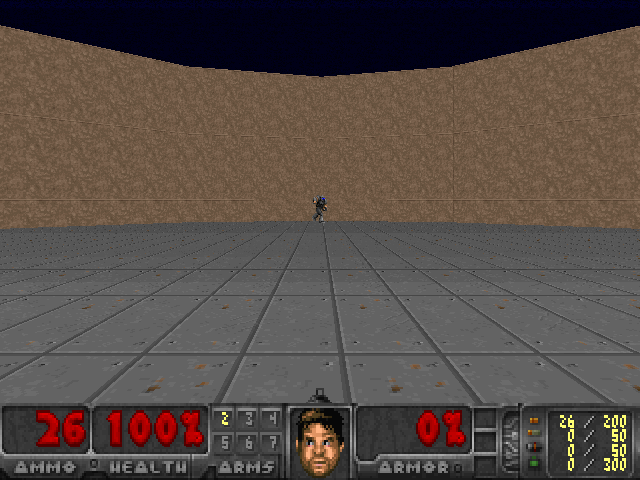

In [ ]:
# @title 4. High-Resolution Recording (640x480) -
import numpy as np
import imageio
import os
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution
from stable_baselines3 import PPO
from IPython.display import Image, display
from gymnasium import spaces # Helper for dummy check

# Configuration
MODEL_PATH = "/content/model_Sentinel.zip"  
OUTPUT_FILE = "/content/logs_morl_final/gameplay_hd.gif"
RESOLUTION = ScreenResolution.RES_640X480  # Much higher than training
FRAME_SKIP = 4

# Choose the personality for playback
# [Kill, Ammo, Pain]
PLAYBACK_WEIGHTS = np.array([0.01, 0.1, 0.8], dtype=np.float32) # Berserker

class VizDoomHD:
    def __init__(self, model_path):
        # Locate Config
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")

        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)

        # Set High Resolution
        self.game.set_screen_resolution(RESOLUTION)
        self.game.init()

        print(f"Loading model from: {model_path}")
        self.model = PPO.load(model_path)

    def preprocess(self, screen_buffer):
        """
        Takes the HD screen (640x480), resizes to (80x60),
        and packs it into the Dict format the agent expects.
        """
        # 1. Resize to Agent's Eye (80x60)
        resized = cv2.resize(screen_buffer, (80, 60), interpolation=cv2.INTER_AREA)

        # 2. Re-order dimensions: (H, W, C) -> (C, H, W)
        img_ch_first = np.transpose(resized, (2, 0, 1))

        # 3. Add Batch Dimension: (1, C, H, W)
        # Note: In SB3 predict(), if you pass a single numpy array, it handles batching,
        # but for complex Dicts, it's safer to be explicit or rely on the env wrapper.
        # However, for manual predict, we simply pass the Dict structure.

        # We need to wrap inputs in the exact Dict structure the model trained on.
        return {
            "image": img_ch_first,      # Shape (3, 60, 80)
            "weights": PLAYBACK_WEIGHTS # Shape (3,)
        }

    def record_episode(self, filename):
        frames = []
        self.game.new_episode()

        print(f"Recording HD Episode with Weights: {PLAYBACK_WEIGHTS}...")

        while not self.game.is_episode_finished():
            state = self.game.get_state()
            hd_screen = state.screen_buffer

            # 1. Save HD frame for video
            frames.append(hd_screen)

            # 2. Preprocess for Agent
            obs_dict = self.preprocess(hd_screen)

            # 3. Predict
            # We pass the dictionary directly.
            # StableBaselines3 automatically handles the lack of batch dim for single observations usually,
            # but if it fails, we might need to expand_dims.
            action, _ = self.model.predict(obs_dict, deterministic=True)

            # 4. Execute Action
            do_action = [0.0] * 3
            do_action[action.item()] = 1.0
            self.game.make_action(do_action, FRAME_SKIP)

        self.game.close()

        print(f"Saving {len(frames)} HD frames to {filename}...")
        imageio.mimsave(filename, frames, fps=25)
        print("Done!")
        display(Image(filename=filename))

# --- Run ---
if os.path.exists(MODEL_PATH):
    recorder = VizDoomHD(MODEL_PATH)
    recorder.record_episode(OUTPUT_FILE)
else:
    print(f"Error: Model not found at {MODEL_PATH}")
    print("Please check the path in CONFIG['log_dir'] from the previous cell.")